# The Friday news dump 🗑️
### Do companies bury bad news on Friday night — and does the stock keep sliding while nobody looks?

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Friday_night_dump%3F: Mixed](https://img.shields.io/badge/Friday_night_dump%3F-Mixed-8b949e?style=flat-square)

Every PR handbook knows the trick: got something ugly to disclose? File it **Friday after the market closes**. Reporters are gone, investors are at dinner, and by Monday it's old news. Finance has a famous paper behind the folklore — DellaVigna & Pollet (2009) found that Friday earnings news gets a weaker immediate reaction and a bigger *delayed* one: the market underreacts, then drifts.

We put both halves under the microscope with the SEC's own filing logs: **3,122 unambiguously-bad 8-K filings** (accounting restatements, asset impairments, CEO exits) timestamped **to the second**, 2004-2026, plus 696 routine earnings filings as the control.

> 📓 **Plain-language layer.** Want the Welch *t*'s, the permutation placebo and the cost stack? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ Every chart is drawn by the code beside it; house style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from friday_news_dump import data, strategy as st

AS_OF = "2026-06-30"
HAVE_REAL = data.have_real()
print("real cache present:", HAVE_REAL,
      "(offline CI runs quote the frozen numbers in R — mirror of docs/results.md)")

# frozen headline numbers (mirror of docs/results.md)
R = {'as_of': '2026-06-30', 'n_filings': 3818, 'n_bad': 3122, 'n_ctrl': 696, 'n_by_class': {'ceo_exit': 1051, 'nonreliance': 1044, 'impairment': 1027}, 'n_mapped': 1234, 'n_car': 1027, 'first': '2004-08-27', 'last': '2026-06-15', 'fp_events': 'e566cab9c587', 'fp_spy': 'c9b5637c9a7f', 'n_sessions': 5658, 'main': {'n_fri': 210, 'n_oth': 817, 'ar0_fri': 65.4, 'ar0_oth': -70.4, 'ar0_t_fri': 0.83, 'ar0_t_oth': -1.79, 'ar0_gap_t': 1.54, 'drift_fri': -45.6, 'drift_oth': -56.3, 'drift_t_fri': -0.4, 'drift_t_oth': -1.06, 'gap': 10.7, 'gap_t': 0.08, 'gap_t_wins': 0.02, 'p_perm': 0.523, 'pooled': -54.1, 'pooled_t': -1.12, 'pooled_t_wins': -1.45, 'car010_gap_t': 1.07, 'pm_n': 130, 'pm_drift': -2.2, 'pm_drift_t': -0.02, 'pm_gap': 59.5, 'pm_gap_t': 0.39}, 'robust': [('nonreliance', 254, 61, 247.6, 0.82, -6.9, -0.05), ('impairment', 526, 91, 109.0, 0.88, -48.7, -1.26), ('ceo_exit', 247, 58, -400.6, -1.39, -114.2, -0.88), ('2004-2015', 344, 62, -63.7, -0.41, -11.2, -0.17), ('2016-2026', 683, 148, 48.0, 0.28, -75.8, -1.17)], 'shares': {'friday': (21.3, 7.9, 10.67), 'after_close': (57.9, 47.6, 4.94), 'friday_pm': (12.8, 1.4, 15.15), 'wd_bad': [19.7, 19.6, 19.4, 20.0, 21.3], 'wd_ctrl': [12.6, 22.7, 29.0, 27.7, 7.9], 'friday_null': 20.3, 'friday_vs_null_z': 1.4}, 'trades': [('Friday filers, borrow 5%/yr', 210, 9.6, 45.6, 0.4, 0.56, 41.8, 3.8, 0.03), ('Friday filers, borrow 2%/yr', 210, 9.6, 45.6, 0.4, 0.56, 29.9, 15.7, 0.14), ('Friday-PM only, borrow 5%/yr', 130, 6.0, 2.2, 0.02, 0.6, 41.8, -39.6, -0.28), ('Friday-PM only, borrow 2%/yr', 130, 6.0, 2.2, 0.02, 0.6, 29.9, -27.7, -0.19)], 'path_fri': [65.4, 28.1, 45.2, 17.0, 64.9, 111.0, 80.7, 57.7, 42.5, 23.8, 19.8], 'path_oth': [-70.4, -106.1, -100.7, -136.1, -109.1, -133.7, -126.7, -145.5, -132.9, -137.4, -126.7], 'syn': [('null', 21.5, -26.2, -0.38, 0.34), ('drift -300 bps Fri', 21.5, -326.2, -4.69, 0.0), ('hide p_fri=0.35', 37.1, -22.3, -0.38, 0.364)]}


real cache present: True (offline CI runs quote the frozen numbers in R — mirror of docs/results.md)


## The answer first

| Question | Answer |
|---|---|
| Do companies time their bad news? | **Yes — but into the *evening*, not into Friday.** 58% of bad 8-Ks land after the 4pm close (routine earnings: 48%). |
| Is Friday night really the dump ground? | **Only compared to other news.** Bad news hits Friday-after-close 12.8% of the time vs 1.4% for earnings — a 9× gap. But bad news is spread almost perfectly flat across the week (Friday 21.3% vs a 20.3% coin-flip baseline). Friday only *looks* special because ordinary news avoids it. |
| Does Friday-filed bad news drift down while nobody looks? | **No.** Over the next ten sessions Friday filers slid -46 bps vs -56 bps for Mon-Thu filers — statistically identical (the gap is 11 bps of noise, *t* ≈ 0.1). |
| Can you short the Friday dump and get paid? | **No.** After realistic costs and borrow the trade makes ~4 bps per event (*t* = 0.03), ten times a year. |

> The *hiding* is real — companies really do slip bad news out after hours. The *market-falls-for-it* half is what fails: by the next close the price has moved, and there is no extra slide left to harvest.

## 1 · The claim

> *"File it Friday after the close. The market underreacts to news nobody reads, so the stock drifts down for weeks — short the dump."*

It is plausible folklore with an academic pedigree: limited attention is one of the best-documented facts in behavioural finance, and DellaVigna-Pollet measured exactly this pattern on Friday *earnings* announcements (1995-2006 data). We test the sharper version: not earnings that might be good or bad, but 8-K classes that are **bad by construction** —

- **Item 4.02** (1,044 filings): "don't rely on our previous accounts" — a restatement is coming;
- **Item 2.06** (1,027): material impairments — assets just lost value;
- **Item 5.02 CEO exits** (1,051): the boss resigned.

Each filing carries the EDGAR **acceptance timestamp** — the second it became public — so "Friday after the close" is measured exactly, not guessed.

## 2 · The hiding — real, but it's about the *clock*, not the *calendar*

First the disclosure-timing question on the **full** panel of 3,122 bad filings (no survivorship here — dead companies' filings count too). If firms dumped bad news on Friday, the Friday bar below should tower over the rest of the week.

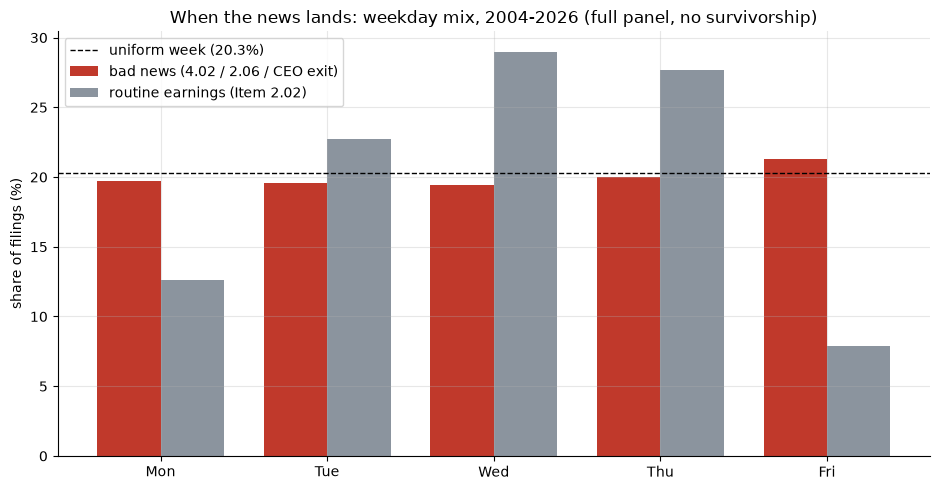

bad news on Friday          : 21.3%  (uniform null 20.3% -> z = +1.40, not significant)
bad news after the close    : 57.9% vs earnings 47.6%  (z = +4.94)
bad news Friday-after-close : 12.8% vs earnings 1.4%  (z = +15.15)


In [2]:
s = R['shares']
x = np.arange(5); w = 0.38
fig, ax = plt.subplots()
ax.bar(x - w/2, s['wd_bad'], w, color=RED, label='bad news (4.02 / 2.06 / CEO exit)')
ax.bar(x + w/2, s['wd_ctrl'], w, color=GREY, label='routine earnings (Item 2.02)')
ax.axhline(s['friday_null'], ls='--', c='k', lw=1,
           label=f"uniform week ({s['friday_null']:.1f}%)")
ax.set_xticks(x, ['Mon', 'Tue', 'Wed', 'Thu', 'Fri'])
ax.set_ylabel('share of filings (%)')
ax.set_title('When the news lands: weekday mix, 2004-2026 (full panel, no survivorship)')
ax.legend()
plt.tight_layout(); plt.show()
print(f"bad news on Friday          : {s['friday'][0]:.1f}%  (uniform null "
      f"{s['friday_null']:.1f}% -> z = {s['friday_vs_null_z']:+.2f}, not significant)")
print(f"bad news after the close    : {s['after_close'][0]:.1f}% vs earnings "
      f"{s['after_close'][1]:.1f}%  (z = {s['after_close'][2]:+.2f})")
print(f"bad news Friday-after-close : {s['friday_pm'][0]:.1f}% vs earnings "
      f"{s['friday_pm'][1]:.1f}%  (z = {s['friday_pm'][2]:+.2f})")


The red bars are almost **flat** — bad news is *not* piled onto Friday. The grey bars explain the legend anyway: routine earnings **avoid** Friday (only 7.9%), so *relative to what you're used to reading*, Friday is disproportionately grim. And the genuine hiding shows up on the clock, not the calendar: **58% of bad 8-Ks land after 4pm** — the Friday-evening *combination* is 9× more common for bad news than for earnings.

> 🔬 **For the quants.** Friday share of bad news vs the uniform-calendar null: binomial z = +1.40. Vs the earnings control: two-proportion z = +10.67. Both are true at once — that contrast IS the finding.

## 3 · The drift — does the market fall for it?

Now the tradable half. For every bad filing we map its timestamp to the first session whose **close** reflects the news (a Friday-9pm filing lands on Monday), subtract the market's move (SPY), and watch ten sessions. DellaVigna-Pollet predicts the **red line** (Friday filers) should sink *further* than the grey one as the ignored news soaks in.

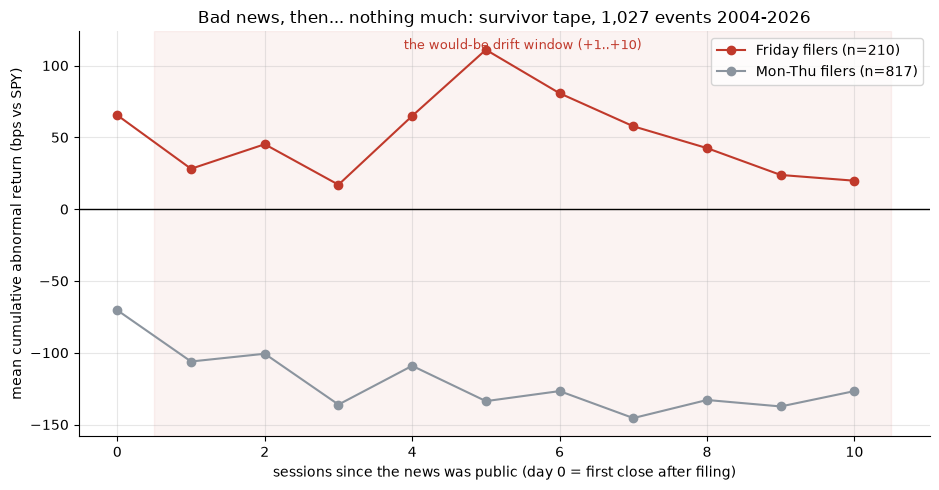

drift day +1..+10: Friday -45.6 bps vs Mon-Thu -56.3 bps -> gap +10.7 bps, Welch t = +0.08
label-permutation placebo p = 0.523  (a fair coin does this half the time)


In [3]:
m = R['main']
t = np.arange(11)
fig, ax = plt.subplots()
ax.plot(t, R['path_fri'], marker='o', color=RED,
        label=f"Friday filers (n={m['n_fri']})")
ax.plot(t, R['path_oth'], marker='o', color=GREY,
        label=f"Mon-Thu filers (n={m['n_oth']})")
ax.axhline(0, c='k', lw=1)
ax.axvspan(0.5, 10.5, alpha=0.06, color=RED)
ax.text(5.5, ax.get_ylim()[1]*0.9, 'the would-be drift window (+1..+10)',
        ha='center', fontsize=9, color=RED)
ax.set_xlabel('sessions since the news was public (day 0 = first close after filing)')
ax.set_ylabel('mean cumulative abnormal return (bps vs SPY)')
ax.set_title('Bad news, then... nothing much: survivor tape, 1,027 events 2004-2026')
ax.legend()
plt.tight_layout(); plt.show()
print(f"drift day +1..+10: Friday {m['drift_fri']:+.1f} bps vs Mon-Thu "
      f"{m['drift_oth']:+.1f} bps -> gap {m['gap']:+.1f} bps, Welch t = {m['gap_t']:+.2f}")
print(f"label-permutation placebo p = {m['p_perm']:.3f}  (a fair coin does this half the time)")


Both groups wobble around **flat**. The Friday line ends the window a whole **11 bps** *above* the weekday line — the wrong direction for the story, and pure noise (*t* ≈ 0.1). Splitting by news class or by decade gives signs both ways, all insignificant.

**One honest caveat, in the open:** our price tape only covers companies that still exist — just 1,234 of 3,122 filers map to a live ticker. The firms that restated and *died* aren't here, so genuine bad-news drift is understated. That censoring hits Friday and Monday filers alike, though — and the Friday-vs-weekday **gap**, which is what the folklore claims, is absent on the tape we can see.

> 🔬 **For the quants.** Pooled drift across all bad news: -54.1 bps/10d, *t* = -1.12 — right sign, below the bar. The full inference table is in notebook 02.

## 4 · "Short the dump" as a trade

Suppose you shorted every Friday-filed bad name at the first close after the news (never catching the day-0 hit — that's gone by the time you can trade), hedged with SPY, covered ten sessions later:

| rule | trades/yr | gross/event | net/event (costs + borrow) |
|---|--:|--:|--:|
| Friday filers, borrow 5%/yr | ~10 | +45.6 bps (*t* = +0.40) | **+3.8 bps** (*t* = +0.03) |
| Friday filers, borrow 2%/yr | ~10 | +45.6 bps (*t* = +0.40) | **+15.7 bps** (*t* = +0.14) |

Ten trades a year, in exactly the small caps where borrow is expensive and spreads are wide, for a net edge statistically indistinguishable from zero. The Friday-*evening*-only variant is net **negative**. There is no trade here.

## 5 · Verdict

| Axis | Stamp |
|---|---|
| Signal — Friday-filed bad news drifts more | **NONE** — gap *t* = +0.08, placebo p = 0.52 (survivor tape, named) |
| Tradability — short the dump | **MIRAGE** — +4 bps/event net, *t* = 0.03 |
| Myth-check — firms dump bad news Friday night | **MIXED** — the dump is real but it's an *after-hours* dump; the Friday tilt is folklore born of everything-else avoiding Friday |

The PR departments are guilty as charged — they really do wait for the closing bell. The *market*, though, doesn't stay fooled long enough to pay you: by the next close the damage is priced, Friday or not.

---
*As-of 2026-06-30; panel fingerprint `e566cab9c587`, SPY tape `c9b5637c9a7f`. Reproduce with `python examples/verify.py`. Sources & method: [docs/references.md](../docs/references.md) · [docs/results.md](../docs/results.md). Research & education, not investment advice.*